# Import Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Load Dataset

In [6]:
df=pd.read_csv(r"C:\Users\Aamir choudhary\OneDrive\Desktop\INNHotelsGroup.csv\INNHotelsGroup.csv")

df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


# Dataset info

In [7]:
df.shape

(36275, 19)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [9]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


# Missing Values Check

In [10]:
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

# Duplicate Check

In [11]:
df.duplicated().sum()

np.int64(0)

# EDA

# Booking Status Distribution

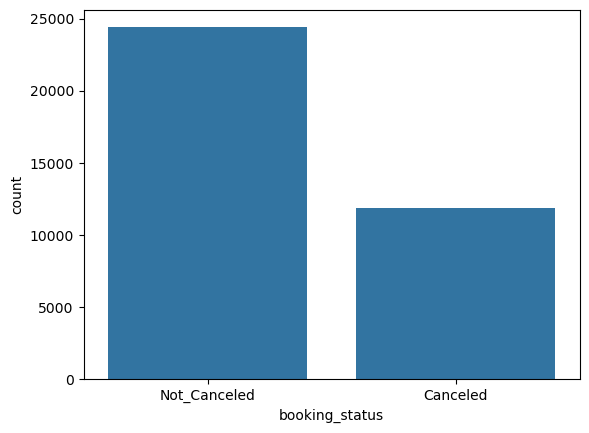

In [12]:
sns.countplot(
x="booking_status",
data=df
)

plt.show()

# Average Room Price

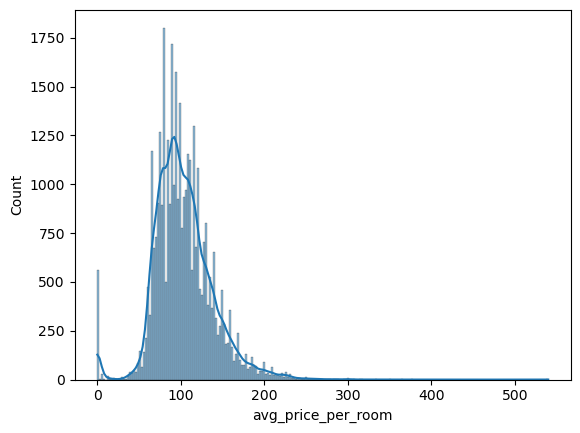

In [13]:
sns.histplot(
df["avg_price_per_room"],
kde=True
)

plt.show()

# Lead Time Distribution

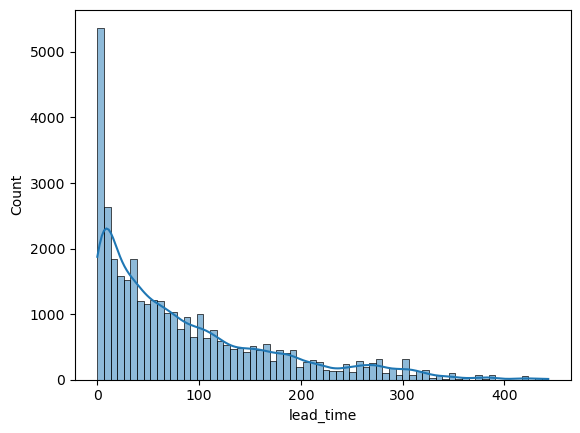

In [14]:
sns.histplot(
df["lead_time"],
kde=True
)

plt.show()

# Meal Plan vs Booking

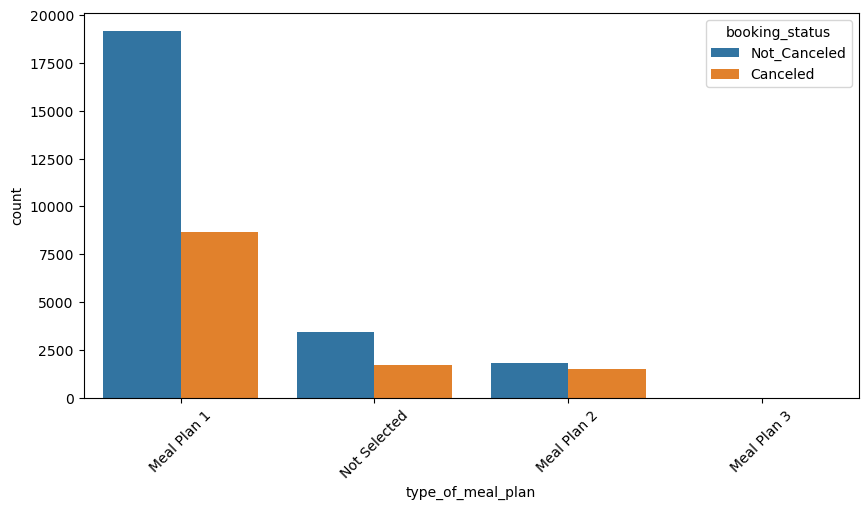

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
x="type_of_meal_plan",
hue="booking_status",
data=df
)

plt.xticks(rotation=45)

plt.show()

# Correlation

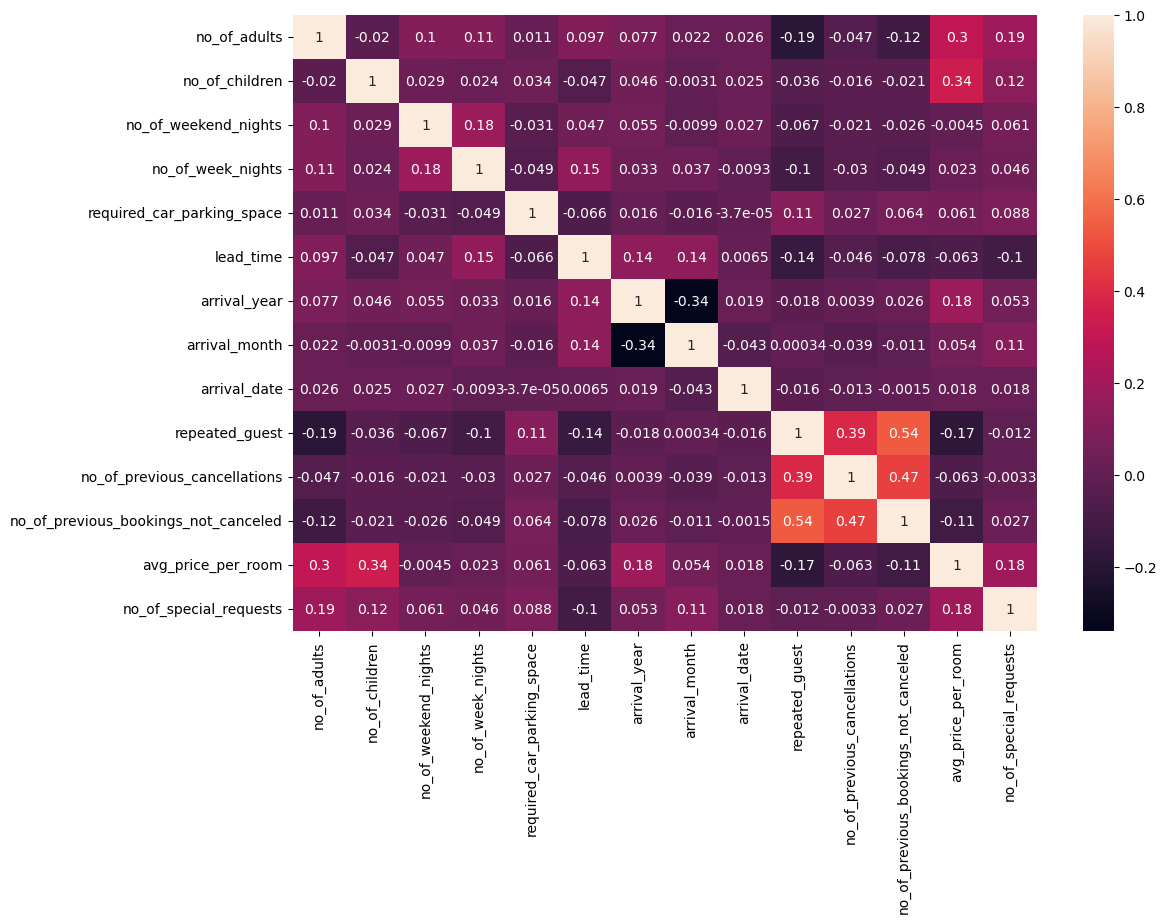

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
df.corr(numeric_only=True),
annot=True
)

plt.show()

# Outlier Check

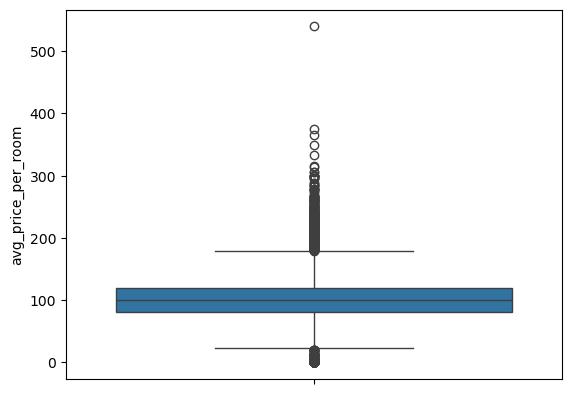

In [17]:
sns.boxplot(
y=df["avg_price_per_room"]
)

plt.show()

# Remove

In [18]:
Q1=df["avg_price_per_room"].quantile(.25)

Q3=df["avg_price_per_room"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

df=df[
(df["avg_price_per_room"]>=lower)&
(df["avg_price_per_room"]<=upper)
]

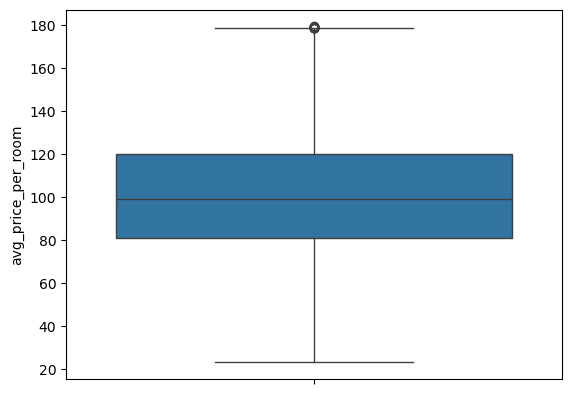

In [19]:
sns.boxplot(
y=df["avg_price_per_room"]
)

plt.show()

# Drop Booking_ID

In [20]:
df.drop(
"Booking_ID",
axis=1,
inplace=True
)

# Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

cat_cols=[
'type_of_meal_plan',
'room_type_reserved',
'market_segment_type',
'booking_status'
]

for i in cat_cols:
    df[i]=le.fit_transform(df[i])

# Features and Target

In [22]:
X=df.drop(
"booking_status",
axis=1
)

y=df["booking_status"]

# Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=\
train_test_split(
X,
y,
test_size=.20,
random_state=42
)

# Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

X_train=sc.fit_transform(X_train)

X_test=sc.transform(X_test)

# Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()

lr.fit(X_train,y_train)

pred1=lr.predict(X_test)

print("Logistic Accuracy:",
      accuracy_score(y_test,pred1))

print(classification_report(y_test,pred1))

Logistic Accuracy: 0.8004626951995373
              precision    recall  f1-score   support

           0       0.76      0.60      0.67      2329
           1       0.82      0.90      0.86      4587

    accuracy                           0.80      6916
   macro avg       0.79      0.75      0.76      6916
weighted avg       0.80      0.80      0.79      6916



# KNN

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

pred2=knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test,pred2))

print(classification_report(y_test,pred2))

KNN Accuracy: 0.8504916136495084
              precision    recall  f1-score   support

           0       0.80      0.74      0.77      2329
           1       0.87      0.91      0.89      4587

    accuracy                           0.85      6916
   macro avg       0.84      0.82      0.83      6916
weighted avg       0.85      0.85      0.85      6916



# Naive Bayes

In [59]:
from sklearn.naive_bayes import GaussianNB

nb=GaussianNB()

nb.fit(X_train,y_train)

pred3=nb.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test,pred3))

print(classification_report(y_test,pred3))

Naive Bayes Accuracy: 0.4407171775592828
              precision    recall  f1-score   support

           0       0.37      0.98      0.54      2329
           1       0.93      0.17      0.29      4587

    accuracy                           0.44      6916
   macro avg       0.65      0.57      0.41      6916
weighted avg       0.75      0.44      0.37      6916



# Decision Tree

In [58]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred4=dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test,pred4))

print(classification_report(y_test,pred4))

Decision Tree Accuracy: 0.8629265471370735
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2329
           1       0.90      0.89      0.90      4587

    accuracy                           0.86      6916
   macro avg       0.85      0.85      0.85      6916
weighted avg       0.86      0.86      0.86      6916



# SVM

In [57]:
from sklearn.svm import SVC

svm=SVC()

svm.fit(X_train,y_train)

pred5=svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test,pred5))

print(classification_report(y_test,pred5))

SVM Accuracy: 0.8458646616541353
              precision    recall  f1-score   support

           0       0.84      0.67      0.75      2329
           1       0.85      0.93      0.89      4587

    accuracy                           0.85      6916
   macro avg       0.84      0.80      0.82      6916
weighted avg       0.84      0.85      0.84      6916



# Compare Models

In [30]:
from sklearn.metrics import accuracy_score

result=pd.DataFrame({

"Model":[
"Logistic",
"KNN",
"Naive Bayes",
"Decision Tree",
"SVM"
],

"Accuracy":[

accuracy_score(y_test,pred1),
accuracy_score(y_test,pred2),
accuracy_score(y_test,pred3),
accuracy_score(y_test,pred4),
accuracy_score(y_test,pred5)

]

})

print(result)

           Model  Accuracy
0       Logistic  0.800463
1            KNN  0.850492
2    Naive Bayes  0.440717
3  Decision Tree  0.866686
4            SVM  0.845865


# Overfit Check Graph

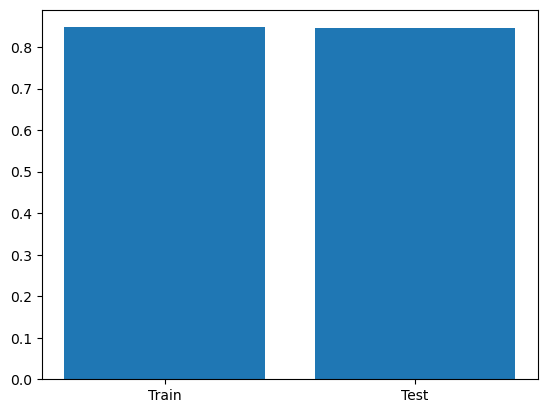

In [40]:
train_pred=svm.predict(X_train)

test_pred=svm.predict(X_test)

train_acc=accuracy_score(
y_train,
train_pred
)

test_acc=accuracy_score(
y_test,
test_pred
)

plt.bar(
["Train","Test"],
[train_acc,test_acc]
)

plt.show()

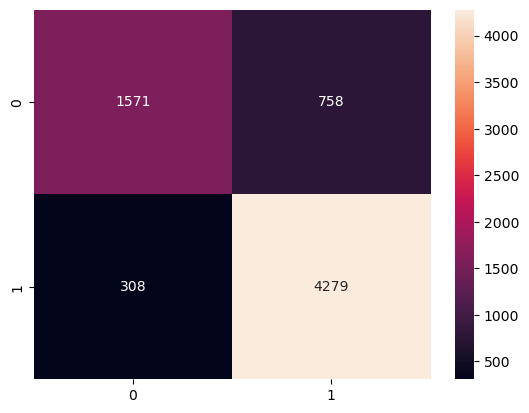

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,pred5)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.show()